# 14 · Positive control — DBS on UPDRS-III (motor) in same cohort

Purpose: demonstrate that the DBS cohort DOES show the expected motor benefit, which validates the data quality and rules out a null-across-the-board interpretation. Uses the same landmark framework as notebook 13.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(purrr); library(lme4); library(emmeans)
})
rel <- load_full_ppmi_rel_patient_anchor()
rel_d <- dedup_earliest_per_bin(rel)
cat("rel_d rows:", nrow(rel_d), "  patients:", dplyr::n_distinct(rel_d$PATNO), "\n")

rel_d rows: 3535   patients: 1484 


In [2]:
# Landmark means for UPDRS-III
landmarks <- c(6, 12, 18, 24, 36, 48, 60)
baseline_m <- rel_d %>% dplyr::filter(months >= -24, months <= 0, !is.na(updrs3_score)) %>%
  dplyr::arrange(PATNO, dplyr::desc(months)) %>%
  dplyr::group_by(PATNO) %>% dplyr::slice_head(n=1) %>% dplyr::ungroup() %>%
  dplyr::select(PATNO, will_receive_dbs, u3_base = updrs3_score)

at_L <- function(L, tol=6) {
  rel_d %>% dplyr::filter(!is.na(updrs3_score), months >= L-tol, months <= L+tol) %>%
    dplyr::mutate(dist = abs(months-L)) %>%
    dplyr::arrange(PATNO, dist) %>% dplyr::group_by(PATNO) %>%
    dplyr::slice_head(n=1) %>% dplyr::ungroup() %>%
    dplyr::select(PATNO, u3_L = updrs3_score) %>% dplyr::mutate(landmark = L)
}
lm_u3 <- purrr::map_dfr(landmarks, at_L) %>%
  dplyr::inner_join(baseline_m, by = "PATNO") %>%
  dplyr::mutate(delta = u3_L - u3_base,
                arm = dplyr::if_else(will_receive_dbs, "DBS", "Never-DBS"))

summ_u3 <- lm_u3 %>% dplyr::group_by(landmark, arm) %>%
  dplyr::summarise(n = dplyr::n(), mean_u3 = mean(u3_L),
                   se = stats::sd(u3_L)/sqrt(n), mean_delta = mean(delta),
                   se_d = stats::sd(delta)/sqrt(n), .groups = "drop") %>%
  dplyr::mutate(lo = mean_u3 - 1.96*se, hi = mean_u3 + 1.96*se,
                lo_d = mean_delta - 1.96*se_d, hi_d = mean_delta + 1.96*se_d)
print(summ_u3)
save_table(summ_u3, "landmark_updrs3")

# A tibble: 14 × 11
   landmark arm          n mean_u3     se mean_delta   se_d    lo    hi     lo_d
      <dbl> <chr>    <int>   <dbl>  <dbl>      <dbl>  <dbl> <dbl> <dbl>    <dbl>
 1        6 DBS         71    30.9  2.06      -5.07  1.61   26.8   34.9  -8.22  
 2        6 Never-D…  1242    21.9  0.329     -0.116 0.0516 21.3   22.6  -0.217 
 3       12 DBS         49    30.6  2.07      -2.73  2.46   26.5   34.6  -7.55  
 4       12 Never-D…   465    23.9  0.507      0.828 0.396  22.9   24.9   0.0524
 5       18 DBS         51    32.6  2.22      -0.412 2.30   28.2   36.9  -4.92  
 6       18 Never-D…   529    24.3  0.479      1.20  0.382  23.4   25.3   0.448 
 7       24 DBS         32    36.9  2.79       4.34  2.89   31.4   42.3  -1.32  
 8       24 Never-D…   240    27.7  0.742      4.65  0.849  26.3   29.2   2.99  
 9       36 DBS         22    36.9  2.53       5.73  4.28   32.0   41.9  -2.67  
10       36 Never-D…   104    28.9  1.40       5.75  1.60   26.2   31.7   2.61  
11      

In [3]:
welch_u3 <- purrr::map_dfr(landmarks, function(L) {
  d1 <- lm_u3 %>% dplyr::filter(landmark == L, arm == "DBS") %>% dplyr::pull(delta)
  d2 <- lm_u3 %>% dplyr::filter(landmark == L, arm == "Never-DBS") %>% dplyr::pull(delta)
  if (length(d1) < 5 || length(d2) < 5) return(tibble::tibble(landmark=L, diff=NA, p=NA))
  tt <- stats::t.test(d1, d2)
  tibble::tibble(landmark = L, diff = mean(d1) - mean(d2),
                 lo = tt$conf.int[1], hi = tt$conf.int[2], p = tt$p.value)
})
print(welch_u3)
save_table(welch_u3, "landmark_updrs3_welch")

# A tibble: 7 × 5
  landmark     diff     lo    hi        p
     <dbl>    <dbl>  <dbl> <dbl>    <dbl>
1        6  -4.95    -8.16 -1.75  0.00293
2       12  -3.56    -8.56  1.43  0.158  
3       18  -1.61    -6.28  3.07  0.493  
4       24  -0.306   -6.41  5.79  0.920  
5       36  -0.0227  -9.41  9.36  0.996  
6       48 -17.2    -31.4  -3.05  0.0244 
7       60  NA       NA    NA    NA      


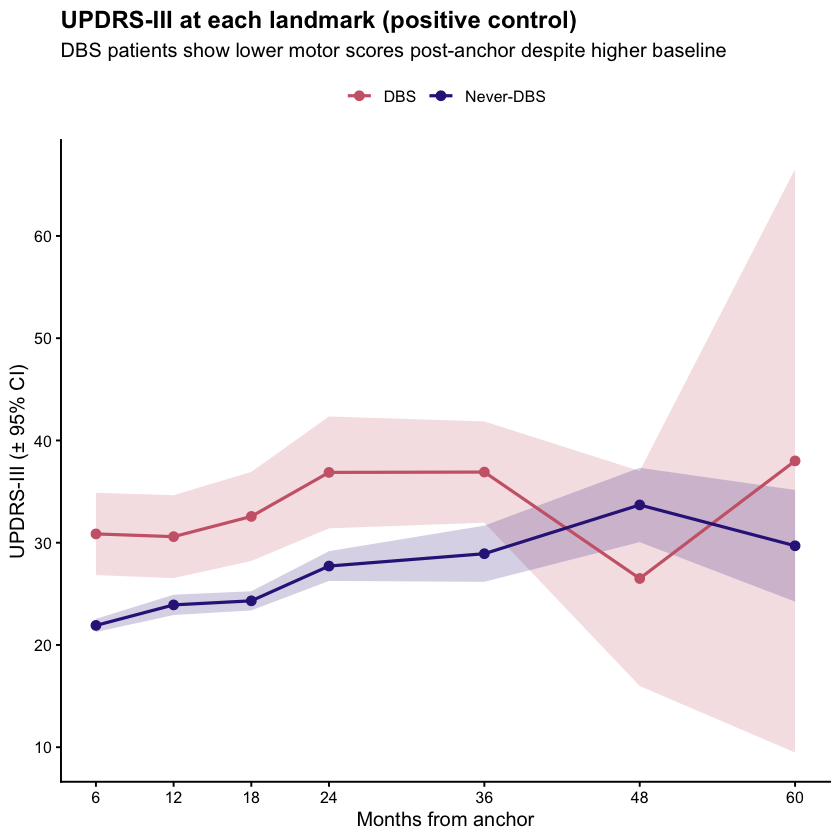

In [4]:
pA <- ggplot(summ_u3, aes(landmark, mean_u3, colour = arm, fill = arm)) +
  geom_ribbon(aes(ymin = lo, ymax = hi), alpha = 0.2, colour = NA) +
  geom_line(linewidth = 0.9) + geom_point(size = 2.3) +
  scale_colour_manual(values = c(`DBS` = "#CC6677", `Never-DBS` = "#332288"), name = NULL) +
  scale_fill_manual(values = c(`DBS` = "#CC6677", `Never-DBS` = "#332288"), guide = "none") +
  scale_x_continuous(breaks = landmarks) +
  labs(title = "UPDRS-III at each landmark (positive control)",
       subtitle = "DBS patients show lower motor scores post-anchor despite higher baseline",
       x = "Months from anchor", y = "UPDRS-III (± 95% CI)") +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold"), legend.position = "top")
pA
save_fig(pA, "Fig24_positive_control_motor", width = 7, height = 4.4)

In [5]:
# LMM for UPDRS-III
lm_data <- rel %>% dplyr::filter(!is.na(updrs3_score)) %>%
  dplyr::mutate(time = time_months / 12,
                arm = factor(dplyr::if_else(will_receive_dbs, "DBS", "Never-DBS"),
                             levels = c("Never-DBS","DBS")))
m_u3 <- lme4::lmer(updrs3_score ~ time * arm + (1 + time | PATNO),
                   data = lm_data, REML = FALSE,
                   control = lme4::lmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5)))
cat("Fixed effects:\n"); print(summary(m_u3)$coefficients)
sl <- emmeans::emtrends(m_u3, specs = "arm", var = "time")
print(sl)
ct <- as.data.frame(pairs(sl))
print(ct)
save_table(ct, "lmm_updrs3_slope_contrasts")

Fixed effects:


              Estimate Std. Error   t value
(Intercept) 24.6135166  0.3431296 71.732424
time         1.1678710  0.1772134  6.590195
armDBS       9.5539900  1.2036729  7.937364
time:armDBS  0.5736144  0.4831510  1.187236


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 24611' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 24611)' or larger];
but be warned that this may result in large computation time and memory use.



Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 24611' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 24611)' or larger];
but be warned that this may result in large computation time and memory use.



 arm       time.trend    SE  df asymp.LCL asymp.UCL
 Never-DBS       1.17 0.177 Inf     0.821      1.52
 DBS             1.74 0.449 Inf     0.861      2.62

Degrees-of-freedom method: asymptotic 
Confidence level used: 0.95 


 contrast            estimate       SE  df z.ratio p.value
 (Never-DBS) - DBS -0.5736144 0.483151 Inf  -1.187  0.2351

Degrees-of-freedom method: asymptotic 
